# Download Data

In [1]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
import os

dataset_path = "/kaggle/input/brain-tumor-mri-dataset"

print(os.listdir(dataset_path))

['Training', 'Testing']


# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout, Conv2D, MaxPool2D, Flatten, Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# Reading Data & Preprocessing

In [ ]:
train_path = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_path = "/kaggle/input/brain-tumor-mri-dataset/Testing"

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 4480 images belonging to 4 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1120 images belonging to 4 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1600 images belonging to 4 classes.


In [ ]:
CLASS_NAMES = list(train_generator.class_indices.keys())
print("Class indices:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Val   samples:", val_generator.samples)
print("Test  samples:", test_generator.samples)

Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train samples: 4480
Val   samples: 1120
Test  samples: 1600


# ANN

## => ANN Takes vecto 1D not 2D Photo, So we do Flatten before.

## Step 1 : Flatten



In [ ]:
def generator_to_numpy(generator):
    """Convert an ImageDataGenerator into NumPy arrays (X, y)"""
    generator.reset()
    X_list, y_list = [], []

    # Iterate over all batches in the generator
    for _ in range(len(generator)):
        X_batch, y_batch = next(generator)
        X_list.append(X_batch)
        y_list.append(y_batch)

    # Concatenate all batches into full arrays
    return np.concatenate(X_list), np.concatenate(y_list)

print("Loading training data...")
X_train, y_train = generator_to_numpy(train_generator)

print("Loading validation data...")
X_val, y_val = generator_to_numpy(val_generator)

print("Loading test data...")
X_test, y_test = generator_to_numpy(test_generator)

# Print dataset shapes
print(f"\nX_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

Loading training data...
Loading validation data...
Loading test data...

X_train: (4480, 224, 224, 3) | X_val: (1120, 224, 224, 3) | X_test: (1600, 224, 224, 3)


In [ ]:
# Each image is converted into a 1D vector
n_pixels = 224 * 224 * 3

# Reshape datasets into (num_samples, num_features)
X_train_flat = X_train.reshape(-1, n_pixels)
X_val_flat   = X_val.reshape(-1, n_pixels)
X_test_flat  = X_test.reshape(-1, n_pixels)

# Display results
print(f"After flattening → each image has {n_pixels:,} features")
print(f"X_train_flat shape: {X_train_flat.shape}")

After flattening → each image has 150,528 features
X_train_flat shape: (4480, 150528)


## Step 2 : Build ANN Model

In [ ]:
ann_model = Sequential([
    Dense(512, activation='relu', input_shape=(n_pixels,)),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(4, activation='softmax')
], name='ANN_BrainTumor')

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    77,070,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,235,588 (294.63 MB)

 Trainable params: 77,235,588 (294.63 MB)

 Non-trainable params: 0 (0.00 B)

## Step 3 : Compile and Training

In [ ]:
ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    )
]

history = ann_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.3161 - loss: 5.9677 - val_accuracy: 0.4321 - val_loss: 1.3122 - learning_rate: 0.0010
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.3025 - loss: 1.3656 - val_accuracy: 0.3223 - val_loss: 1.3442 - learning_rate: 0.0010
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.3051 - loss: 1.3715 - val_accuracy: 0.2643 - val_loss: 1.3582 - learning_rate: 0.0010
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.2779 - loss: 1.3644 - val_accuracy: 0.2732 - val_loss: 1.3743 - learning_rate: 0.0010
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.2808 - loss: 1.3716 - val_accuracy: 0.3705 - val_loss: 1.3252 - learning_rate: 0.0010
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3063 - loss: 1.3652
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
70/70 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.2929 - loss: 1.3798 - val_accura

## Step 4 : Evaluate the Model

In [ ]:
test_loss, test_acc = ann_model.evaluate(X_test_flat, y_test, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Loss    : 1.3341
Test Accuracy: 44.81%


In [ ]:
y_pred = np.argmax(ann_model.predict(X_test_flat), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step
              precision    recall  f1-score   support

      glioma       0.40      0.41      0.41       400
  meningioma       0.29      0.26      0.28       400
     notumor       0.52      0.78      0.63       400
   pituitary       0.58      0.34      0.43       400

    accuracy                           0.45      1600
   macro avg       0.45      0.45      0.43      1600
weighted avg       0.45      0.45      0.43      1600



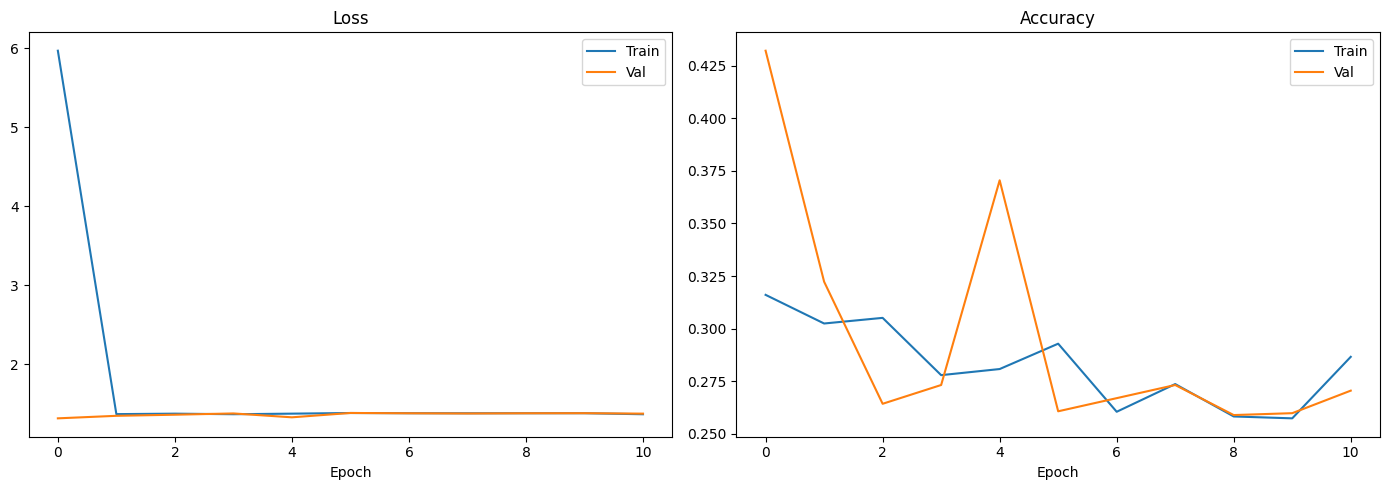

In [ ]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

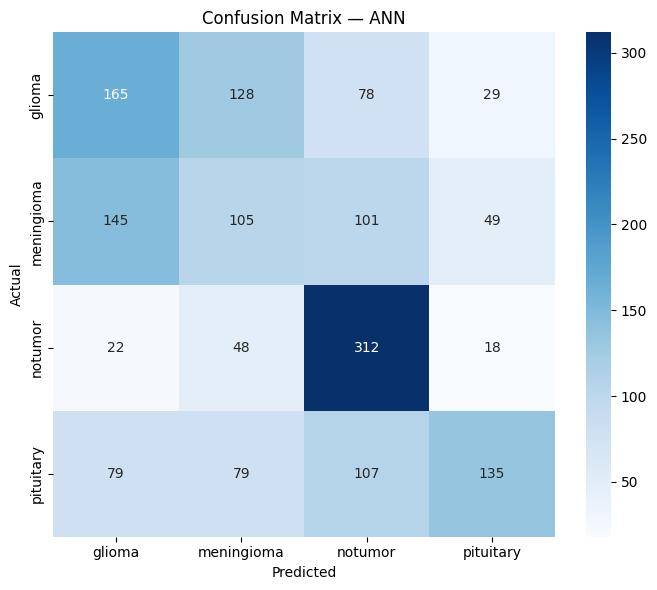

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — ANN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# CNN

## Step 1 : Building the CNN Model

In [ ]:
cnn_model = Sequential([

    Conv2D(32, (3, 3), padding='same', activation='relu',
           input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPool2D(2, 2),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
], name='CNN_BrainTumor')

cnn_model.summary()

## Step 2 : Compile & Train

In [ ]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_cnn.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]


history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.5020 - loss: 13.7494
Epoch 1: val_accuracy improved from None to 0.25000, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 111s 717ms/step - accuracy: 0.5069 - loss: 6.1924 - val_accuracy: 0.2500 - val_loss: 38.5781 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.4970 - loss: 1.2560
Epoch 2: val_accuracy improved from 0.25000 to 0.37321, saving model to best_cnn.keras

Epoch 2: finished saving model to best_cnn.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 569ms/step - accuracy: 0.5179 - loss: 1.3290 - val_accuracy: 0.3732 - val_loss: 2.3618 - learning_rate: 0.0010
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.5405 - loss: 1.1314
Epoch 3: val_accuracy did not improve from 0.37321
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 529ms/step - accuracy: 0.5598 - loss: 1.1011 - val_accuracy: 0.3554 - val_loss: 1.4127 - l

## Step 3 : Evaluate the Model

In [ ]:
test_generator.reset()
test_loss, test_acc = cnn_model.evaluate(test_generator, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Loss    : 1.7099
Test Accuracy: 81.31%


In [ ]:
test_generator.reset()
y_pred = np.argmax(cnn_model.predict(test_generator), axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step
              precision    recall  f1-score   support

      glioma       0.85      0.72      0.78       400
  meningioma       0.81      0.57      0.67       400
     notumor       0.77      0.99      0.87       400
   pituitary       0.83      0.97      0.90       400

    accuracy                           0.81      1600
   macro avg       0.82      0.81      0.80      1600
weighted avg       0.82      0.81      0.80      1600



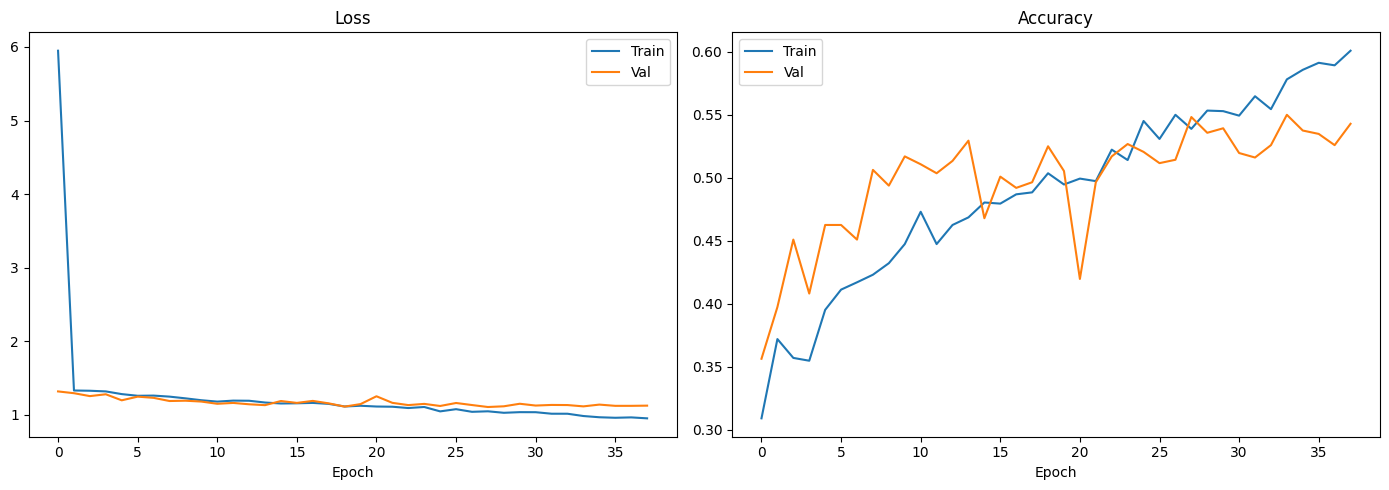

In [ ]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

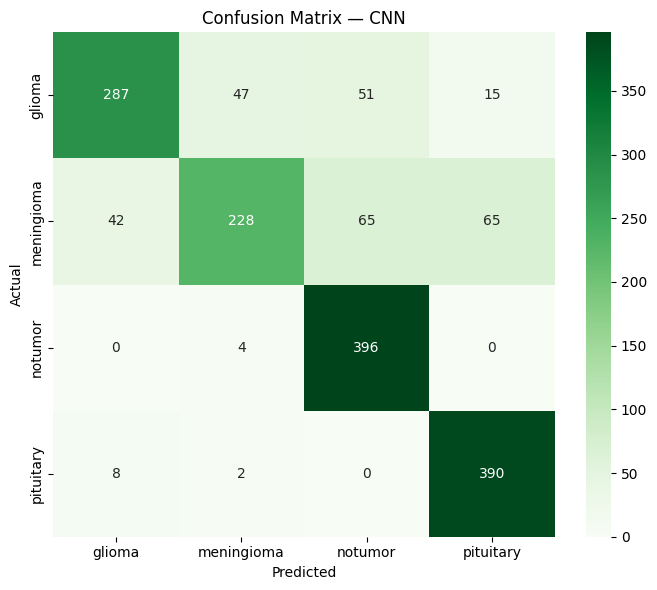

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


# Transfer learning

## Import Libraries

In [3]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.models import Model

## Reading Data & Preprocessing

In [6]:
transfer_datagen_train_val = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [7]:
transfer_datagen_test=ImageDataGenerator(preprocessing_function=preprocess_input)

In [8]:
transfer_train=transfer_datagen_train_val.flow_from_directory('/kaggle/input/brain-tumor-mri-dataset/Training',
                                    target_size=(224,224),
                                    batch_size=32,
                                    subset='training')

Found 4480 images belonging to 4 classes.


In [9]:
transfer_val=transfer_datagen_train_val.flow_from_directory('/kaggle/input/brain-tumor-mri-dataset/Training',
                                    target_size=(224,224),
                                    batch_size=32,
                                    subset='validation')

Found 1120 images belonging to 4 classes.


In [26]:
transfer_test=transfer_datagen_test.flow_from_directory('/kaggle/input/brain-tumor-mri-dataset/Testing',
                                    target_size=(224,224),
                                    batch_size=32,
                                    shuffle=False)

Found 1600 images belonging to 4 classes.


## building the Transfer Model

In [17]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

In [18]:
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(32, activation="relu")(x)
x = Dense(16, activation="relu")(x)
outputs = Dense(4, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=outputs)

In [19]:
callback = keras.callbacks.EarlyStopping(monitor='val_loss',patience=3)

In [20]:
transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Model Training

In [21]:
history = transfer_model.fit(transfer_train, epochs=15, validation_data=transfer_val,callbacks=[callback])

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 139ms/step - accuracy: 0.5734 - loss: 1.1685 - val_accuracy: 0.8357 - val_loss: 0.4639
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.8078 - loss: 0.5315 - val_accuracy: 0.8955 - val_loss: 0.3289
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.8821 - loss: 0.3410 - val_accuracy: 0.8911 - val_loss: 0.3084
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step - accuracy: 0.9143 - loss: 0.2437 - val_accuracy: 0.8991 - val_loss: 0.3008
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accuracy: 0.9397 - loss: 0.1709 - val_accuracy: 0.9214 - val_loss: 0.2401
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - accuracy: 0.9442 - loss: 0.1883 - val_accuracy: 0.9339 - val_loss: 0.2181
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - accuracy: 0.9654 - loss: 0.1139 - val_accuracy: 0.9366 - val_loss: 0.2017
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 110ms/step - accuracy: 0.9779 - loss: 0

## Model Testing & Evaluation

In [27]:
CLASS_NAMES = list(transfer_train.class_indices.keys())

print('Evaluating Transfer Learning Model...')
loss, accuracy = transfer_model.evaluate(transfer_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

print('\nGenerating Classification Report...')
transfer_test.reset()
y_pred_transfer = np.argmax(transfer_model.predict(transfer_test), axis=1)
y_true_transfer = transfer_test.classes

print(classification_report(y_true_transfer, y_pred_transfer, target_names=CLASS_NAMES))



Evaluating Transfer Learning Model...
Test Loss: 0.4337
Test Accuracy: 91.31%

Generating Classification Report...
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step
              precision    recall  f1-score   support

      glioma       0.93      0.79      0.85       400
  meningioma       0.82      0.90      0.86       400
     notumor       0.96      0.99      0.98       400
   pituitary       0.95      0.97      0.96       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.91      1600
weighted avg       0.92      0.91      0.91      1600



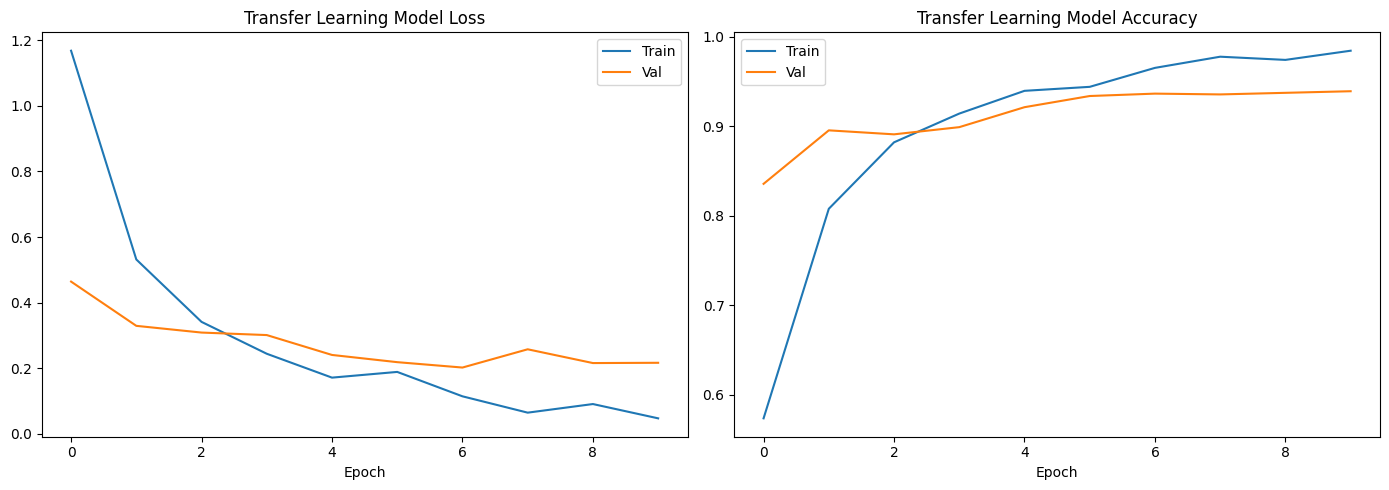

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Transfer Learning Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Transfer Learning Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()



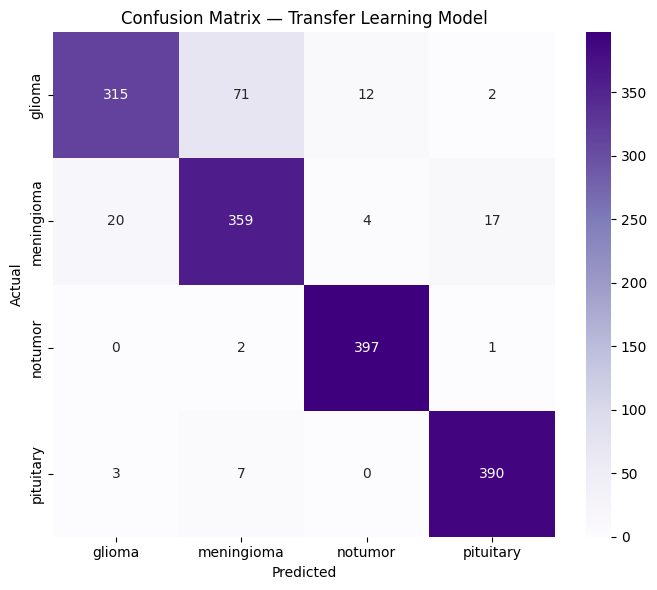

In [29]:
cm_transfer = confusion_matrix(y_true_transfer, y_pred_transfer)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Transfer Learning Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
cnn_model = Sequential([

    Conv2D(32, (3, 3), padding='same', activation='relu',
           input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPool2D(2, 2),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
], name='CNN_BrainTumor')

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,785,540 (98.36 MB)

 Trainable params: 25,785,092 (98.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
transfer_model.save("brain_tumor_model.keras", include_optimizer=False)

In [ ]:
from tensorflow import keras
model = keras.models.load_model("brain_tumor_model.keras")